## Cross-Notebook Synthesis: Refugee Population Pressure and Learning Outcomes by Region

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


math_df = pd.read_csv("clean_math_primary_structured.csv")
reading_df = pd.read_csv("clean_read_primary_structured.csv")
region_df = pd.read_csv("school_age_refugee_population_by_region.csv")

print(math_df.shape, reading_df.shape, region_df.shape)

(558, 6) (488, 6) (154, 3)


## Relationship Between Refugee Population Pressure and Primary Learning Outcomes (2019)

In [ ]:
def pick_col(df, candidates_exact=None, candidates_contains=None, required=True):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}

    
    if candidates_exact:
        for cand in candidates_exact:
            if cand.lower() in lower_map:
                return lower_map[cand.lower()]

    
    if candidates_contains:
        for c in cols:
            cl = c.lower()
            if any(sub.lower() in cl for sub in candidates_contains):
                return c

    if required:
        raise ValueError(f"Could not find column. Available columns: {cols}")
    return None

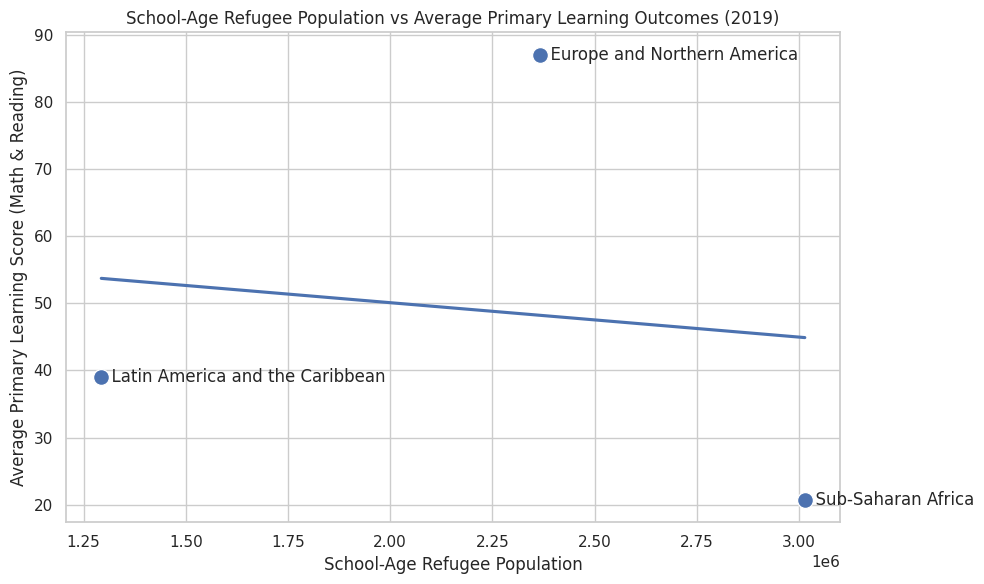

In [ ]:
plt.figure(figsize=(10, 6))


merged["avg_learning_score"] = (merged["math_score"] + merged["reading_score"]) / 2


sns.scatterplot(
    data=merged,
    x="school_age_refugee_population",
    y="avg_learning_score",
    s=130
)

sns.regplot(
    data=merged,
    x="school_age_refugee_population",
    y="avg_learning_score",
    scatter=False,
    ci=None
)


for _, row in merged.iterrows():
    plt.text(row["school_age_refugee_population"], row["avg_learning_score"],
             "  " + row["region_standard"], va="center")

plt.title(f"School-Age Refugee Population vs Average Primary Learning Outcomes ({analysis_year})")
plt.xlabel("School-Age Refugee Population")
plt.ylabel("Average Primary Learning Score (Math & Reading)")
plt.tight_layout()
plt.show()

**Insight:**  
This scatter plot compares regional school-age refugee population size with the
average primary learning score (mean of math and reading). The fitted line
suggests a possible negative association, but the small number of regions means
this result should be treated as exploratory rather than causal. Still, it helps
connect structural pressure and early learning gaps that may influence future
higher-education readiness.